# EDA thống nhất — BĐS Chợ Tốt (5 category)

1. Contact concentration (explicit, login)
2. Duplicate dim sau time coverage
3. Demand-side (5 category, login)
4. 1020 hesitation / reassurance market
5. Login vs non-login + chat_message_count QA
6. Synthesis

**RAM:** `SAMPLE_PCT=5` SYSTEM sample. Part 4 dùng `filtered_events.parquet` nếu có.

Metric user-level chỉ login; sample 5% ổn cho median/rank concentration.


In [1]:
%matplotlib inline
from __future__ import annotations

import warnings
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

WORKDIR = Path.cwd().resolve()
if not (WORKDIR / "dim_listing").exists() and (WORKDIR.parent / "dim_listing").exists():
    DATA_ROOT = WORKDIR.parent
else:
    DATA_ROOT = WORKDIR
if not (DATA_ROOT / "dim_listing").exists():
    raise FileNotFoundError(f"Thiếu dim_listing trong {DATA_ROOT}")

DIM_GLOB = str(DATA_ROOT / "dim_listing" / "*.parquet")
EVENTS_GLOB = str(DATA_ROOT / "fact_user_events" / "*.parquet")
SNAP_GLOB = str(DATA_ROOT / "fact_listing_snapshot" / "*.parquet")
INTER_GLOB = str(DATA_ROOT / "fact_post_contact_interactions" / "*.parquet")
FILTERED_FILE = DATA_ROOT / "Thinh_Analyze" / "filtered_events.parquet"

SAMPLE_PCT = 5
SAMPLE_PCT_QA = 10
USE_FILTERED = FILTERED_FILE.exists()
EXPORT_CSV = True
CAT_1020 = 1020

EXPLICIT_TYPES = ("view_phone", "contact_chat", "contact_zalo", "contact_sms")
POSITIVE_TYPES = EXPLICIT_TYPES + ("other_interaction",)
EXPLICIT_SQL = ", ".join(repr(x) for x in EXPLICIT_TYPES)
POSITIVE_SQL = ", ".join(repr(x) for x in POSITIVE_TYPES)
LOGIN_WHERE = "is_login = 'login'"
CAT_IN = "1010, 1020, 1030, 1040, 1050"

CAT_META = {
    1010: "1010 — Căn hộ / Chung cư",
    1020: "1020 — Nhà ở",
    1030: "1030 — Văn phòng / Mặt bằng",
    1040: "1040 — Đất",
    1050: "1050 — Phòng trọ",
}
CATEGORIES = tuple(CAT_META)

OUT = {
    "concentration": DATA_ROOT / "Thinh_Analyze" / "outputs" / "contact_concentration",
    "duplicate": DATA_ROOT / "Thinh_Analyze" / "outputs" / "dim_duplicate_after_timecut",
    "demand": DATA_ROOT / "Thinh_Analyze" / "outputs" / "demand_side_1020",
    "deep1020": DATA_ROOT / "Thinh_Analyze" / "outputs" / "demand_side_1020" / "1020_deep_dive",
    "nonlogin": DATA_ROOT / "Thinh_Analyze" / "outputs" / "nonlogin_chat_qa",
}
for p in OUT.values():
    p.mkdir(parents=True, exist_ok=True)

con = duckdb.connect(":memory:")
con.execute("PRAGMA threads=4")


def gini(values: np.ndarray) -> float:
    x = np.asarray(values, dtype=np.float64)
    x = x[x > 0]
    if x.size == 0:
        return float("nan")
    x = np.sort(x)
    n = x.size
    return float((2 * np.arange(1, n + 1) - n - 1) @ x / (n * x.sum()))


def top_pct_share(values: np.ndarray, top_pct: float) -> float:
    x = np.sort(values)[::-1]
    total = float(x.sum())
    if total == 0:
        return float("nan")
    k = max(1, int(np.ceil(len(x) * top_pct / 100.0)))
    return 100.0 * float(x[:k].sum()) / total


def concentration_row(entity: str, counts: np.ndarray) -> dict:
    cl = gini(counts)
    return {
        "entity": entity,
        "n_with_contact": int(len(counts)),
        "total_contacts": int(counts.sum()),
        "gini": round(cl, 4),
        "top_10pct_share": round(top_pct_share(counts, 10), 2),
    }


def show_df(df: pd.DataFrame, title: str):
    display(Markdown(f"**{title}**"))
    display(df)


def save_fig(path: Path, dpi: int = 120):
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    try:
        get_ipython()  # type: ignore[name-defined]
        plt.show()
    except NameError:
        pass
    plt.close()
    print("Saved", path)


EDA_MIN, EDA_MAX = con.execute(
    f"SELECT MIN(date), MAX(date) FROM read_parquet('{EVENTS_GLOB}')"
).fetchone()
print("DATA_ROOT =", DATA_ROOT)
print("EDA window:", EDA_MIN, "→", EDA_MAX)
print(f"SAMPLE_PCT={SAMPLE_PCT}% | SAMPLE_PCT_QA={SAMPLE_PCT_QA}% | USE_FILTERED={USE_FILTERED}")


DATA_ROOT = /Users/dothinh_3112/Downloads/Datathon_Data
EDA window: 2025-11-09 → 2026-04-09
SAMPLE_PCT=5% | SAMPLE_PCT_QA=10% | USE_FILTERED=True


## Part 1 — Contact concentration (explicit, login)

Explicit = `view_phone`, `contact_chat`, `contact_zalo`, `contact_sms`. User metrics: `is_login = 'login'`.


**Time coverage**

,src,t_min,t_max,n_rows
0,dim_listing.posted_date,2024-09-15,2026-04-09,3107114
1,fact_user_events.date,2025-11-09,2026-04-09,161731336


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**Contact concentration — summary (sample 5%)**

,category,category_label,listing_gini,listing_top_10pct_share,user_gini,user_top_10pct_share,total_explicit_contacts
0,1010,1010 — Căn hộ / Chung cư,0.2978,28.15,0.3307,33.83,31368
1,1020,1020 — Nhà ở,0.3563,31.67,0.5015,46.94,90775
2,1030,1030 — Văn phòng / Mặt bằng,0.2834,26.58,0.4089,40.16,14580
3,1040,1040 — Đất,0.2817,27.46,0.4161,40.13,20467
4,1050,1050 — Phòng trọ,0.4010,34.46,0.2811,28.45,46092


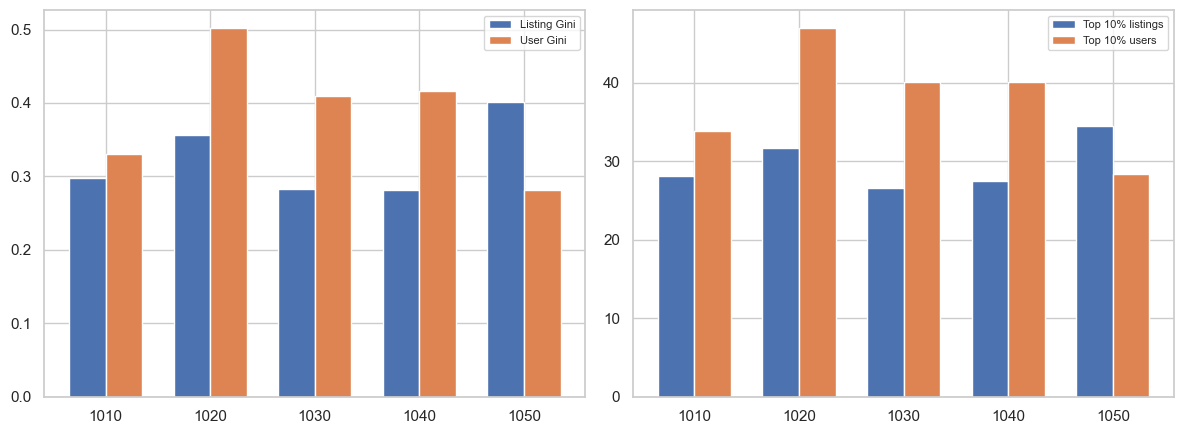

Saved /Users/dothinh_3112/Downloads/Datathon_Data/Thinh_Analyze/outputs/contact_concentration/fig_01_gini_and_top10_share.png


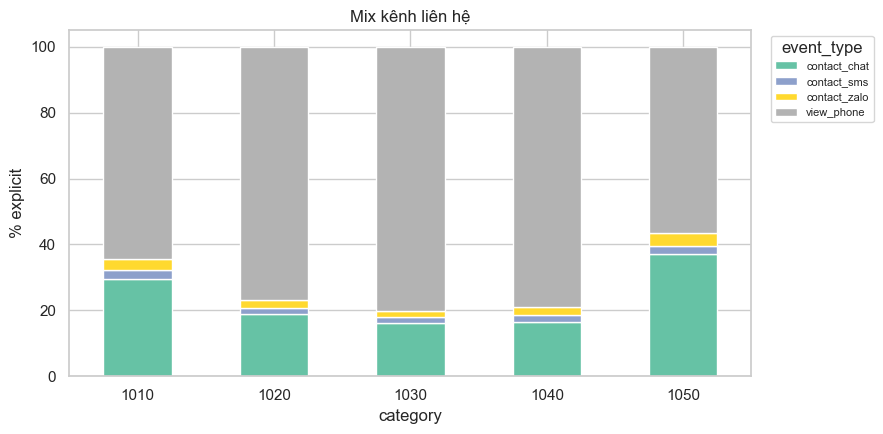

Saved /Users/dothinh_3112/Downloads/Datathon_Data/Thinh_Analyze/outputs/contact_concentration/fig_02_channel_mix.png


In [2]:
time_cov = con.execute(f'''
    SELECT * FROM (
        SELECT 'dim_listing.posted_date' AS src,
               CAST(MIN(posted_date) AS DATE) AS t_min,
               CAST(MAX(posted_date) AS DATE) AS t_max,
               COUNT(*)::BIGINT AS n_rows
        FROM read_parquet('{DIM_GLOB}')
        UNION ALL
        SELECT 'fact_user_events.date', MIN(date), MAX(date), COUNT(*)::BIGINT
        FROM read_parquet('{EVENTS_GLOB}')
    ) ORDER BY 1
''').df()
show_df(time_cov, "Time coverage")
if EXPORT_CSV:
    time_cov.to_csv(OUT["concentration"] / "00_time_coverage.csv", index=False)

con.execute(f'''
    CREATE OR REPLACE TEMP TABLE explicit_ev AS
    SELECT category, user_id, CAST(item_id AS VARCHAR) AS item_id, event_type
    FROM read_parquet('{EVENTS_GLOB}')
    TABLESAMPLE {SAMPLE_PCT} PERCENT (SYSTEM)
    WHERE {LOGIN_WHERE} AND category IN ({CAT_IN})
      AND event_type IN ({EXPLICIT_SQL}) AND item_id IS NOT NULL
''')

listing_all = con.execute(
    "SELECT category, item_id, COUNT(*)::BIGINT AS contacts FROM explicit_ev GROUP BY 1, 2"
).df()
user_all = con.execute(
    "SELECT category, user_id, COUNT(*)::BIGINT AS contacts FROM explicit_ev GROUP BY 1, 2"
).df()
channel_all = con.execute(
    "SELECT category, event_type, COUNT(*)::BIGINT AS contacts FROM explicit_ev GROUP BY 1, 2"
).df()
channel_all["pct_of_explicit"] = channel_all.groupby("category")["contacts"].transform(
    lambda s: (100.0 * s / s.sum()).round(2)
)

summary_rows = []
for cat in CATEGORIES:
    lc = listing_all.loc[listing_all["category"] == cat, "contacts"].to_numpy()
    uc = user_all.loc[user_all["category"] == cat, "contacts"].to_numpy()
    cl = concentration_row("listing", lc)
    cu = concentration_row("user", uc)
    summary_rows.append({
        "category": cat,
        "category_label": CAT_META[cat],
        "listing_gini": cl["gini"],
        "listing_top_10pct_share": cl["top_10pct_share"],
        "user_gini": cu["gini"],
        "user_top_10pct_share": cu["top_10pct_share"],
        "total_explicit_contacts": cl["total_contacts"],
    })

summary_p1 = pd.DataFrame(summary_rows)
show_df(summary_p1, f"Contact concentration — summary (sample {SAMPLE_PCT}%)")
if EXPORT_CSV:
    summary_p1.to_csv(OUT["concentration"] / "01_summary_all_categories.csv", index=False)
    channel_all.to_csv(OUT["concentration"] / "02_channel_mix_by_category.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = np.arange(len(summary_p1))
w = 0.35
axes[0].bar(x - w / 2, summary_p1["listing_gini"], width=w, label="Listing Gini")
axes[0].bar(x + w / 2, summary_p1["user_gini"], width=w, label="User Gini")
axes[0].set_xticks(x)
axes[0].set_xticklabels(summary_p1["category"].astype(str))
axes[0].legend(fontsize=8)
axes[1].bar(x - w / 2, summary_p1["listing_top_10pct_share"], width=w, label="Top 10% listings")
axes[1].bar(x + w / 2, summary_p1["user_top_10pct_share"], width=w, label="Top 10% users")
axes[1].set_xticks(x)
axes[1].set_xticklabels(summary_p1["category"].astype(str))
axes[1].legend(fontsize=8)
save_fig(OUT["concentration"] / "fig_01_gini_and_top10_share.png")

piv = channel_all.pivot(index="category", columns="event_type", values="pct_of_explicit").fillna(0)
piv = piv.reindex(CATEGORIES)
piv.plot(kind="bar", stacked=True, figsize=(9, 4.5), colormap="Set2", edgecolor="white")
plt.ylabel("% explicit")
plt.title("Mix kênh liên hệ")
plt.xticks(rotation=0)
plt.legend(title="event_type", bbox_to_anchor=(1.02, 1), fontsize=8)
save_fig(OUT["concentration"] / "fig_02_channel_mix.png")


## Part 2 — Duplicate dim sau time coverage

`dim_listing` scoped `posted_date` trong cửa sổ EDA từ events (full min/max).


**Duplicate levels**

,dup_level,duplicate_groups,rows_in_dup_groups,pct_rows_in_dup_groups,groups_same_seller,groups_multi_seller
0,L1_title_category,7904,27122,5.57,4485,3419
1,L2_title_geo_price,6616,16815,3.45,3974,2642
2,L3_title_full_fingerprint,2696,5907,1.21,2696,0
3,L4_title_seller,5409,13392,2.75,5409,0


**L2 by category**

,category,duplicate_groups,rows_in_dup_groups,pct_cat,same_seller,multi_seller
0,1010,1536,3681,3.98,1207,329
1,1020,2379,6118,2.65,1288,1091
2,1030,567,1303,3.21,319,248
3,1040,397,865,1.53,261,136
4,1050,1737,4848,7.28,899,838


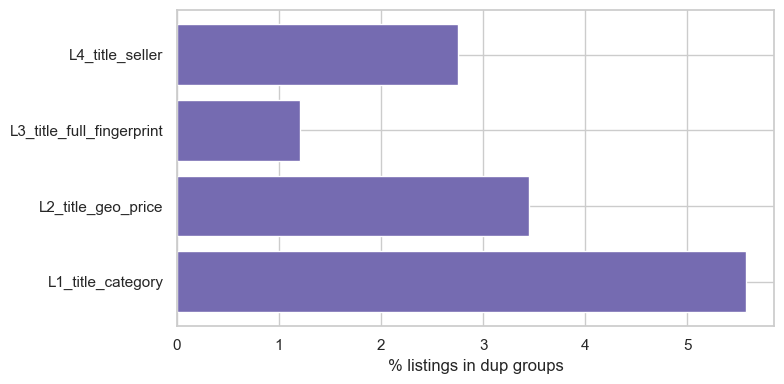

Saved /Users/dothinh_3112/Downloads/Datathon_Data/Thinh_Analyze/outputs/dim_duplicate_after_timecut/fig_duplicate_levels.png


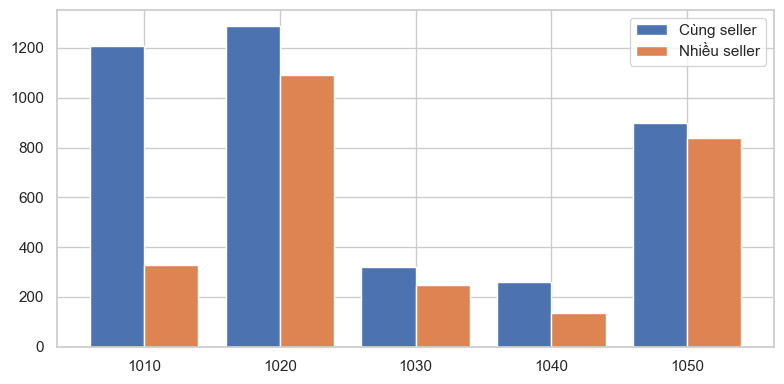

Saved /Users/dothinh_3112/Downloads/Datathon_Data/Thinh_Analyze/outputs/dim_duplicate_after_timecut/fig_L2_same_vs_multi_seller.png


In [3]:
con.execute(f'''
    CREATE OR REPLACE TEMP TABLE dim_scoped AS
    SELECT CAST(item_id AS VARCHAR) AS item_id, seller_id, category, ad_type,
        title, regexp_replace(lower(trim(coalesce(title,''))), '\\s+', ' ', 'g') AS title_norm,
        regexp_replace(lower(trim(coalesce(city_name,''))), '\\s+', ' ', 'g') AS city_norm,
        regexp_replace(lower(trim(coalesce(district_name,''))), '\\s+', ' ', 'g') AS district_norm,
        regexp_replace(lower(trim(coalesce(ward_name,''))), '\\s+', ' ', 'g') AS ward_norm,
        regexp_replace(lower(trim(coalesce(price_bucket,''))), '\\s+', ' ', 'g') AS price_norm,
        area_sqm
    FROM read_parquet('{DIM_GLOB}')
    WHERE posted_date BETWEEN DATE '{EDA_MIN}' AND DATE '{EDA_MAX}'
      AND title IS NOT NULL AND trim(title) <> ''
''')

LEVELS = {
    "L1_title_category": "title_norm, category",
    "L2_title_geo_price": "title_norm, category, ad_type, city_norm, district_norm, price_norm",
    "L3_title_full_fingerprint": (
        "title_norm, category, ad_type, seller_id, city_norm, district_norm, ward_norm, "
        "price_norm, round(coalesce(area_sqm,-1),1)"
    ),
    "L4_title_seller": "title_norm, category, seller_id",
}
n_scoped = con.execute("SELECT COUNT(*) FROM dim_scoped").fetchone()[0]
level_rows = []
for level_name, group_cols in LEVELS.items():
    row = con.execute(
        f'''
        WITH grp AS (
            SELECT {group_cols}, COUNT(*)::BIGINT AS n_items,
                   COUNT(DISTINCT seller_id) AS n_sellers
            FROM dim_scoped GROUP BY ALL HAVING COUNT(*) > 1
        )
        SELECT '{level_name}' AS dup_level,
            COUNT(*)::BIGINT AS duplicate_groups,
            COALESCE(SUM(n_items),0)::BIGINT AS rows_in_dup_groups,
            ROUND(100.0*COALESCE(SUM(n_items),0)/{n_scoped},2) AS pct_rows_in_dup_groups,
            COALESCE(SUM(CASE WHEN n_sellers=1 THEN 1 ELSE 0 END),0)::BIGINT AS groups_same_seller,
            COALESCE(SUM(CASE WHEN n_sellers>1 THEN 1 ELSE 0 END),0)::BIGINT AS groups_multi_seller
        FROM grp
        '''
    ).df().iloc[0].to_dict()
    level_rows.append(row)

dup_summary = pd.DataFrame(level_rows)
show_df(dup_summary, "Duplicate levels")
if EXPORT_CSV:
    dup_summary.to_csv(OUT["duplicate"] / "01_duplicate_levels_summary.csv", index=False)

by_cat = con.execute(
    '''
    WITH grp AS (
        SELECT category, title_norm, ad_type, city_norm, district_norm, price_norm,
               COUNT(*)::BIGINT AS n_items, COUNT(DISTINCT seller_id) AS n_sellers
        FROM dim_scoped GROUP BY ALL HAVING COUNT(*) > 1
    )
    SELECT category, COUNT(*)::BIGINT AS duplicate_groups,
        SUM(n_items)::BIGINT AS rows_in_dup_groups,
        ROUND(100.0*SUM(n_items)/(SELECT COUNT(*) FROM dim_scoped d WHERE d.category=grp.category),2) AS pct_cat,
        SUM(CASE WHEN n_sellers=1 THEN 1 ELSE 0 END)::BIGINT AS same_seller,
        SUM(CASE WHEN n_sellers>1 THEN 1 ELSE 0 END)::BIGINT AS multi_seller
    FROM grp GROUP BY 1 ORDER BY 1
    '''
).df()
show_df(by_cat, "L2 by category")
if EXPORT_CSV:
    by_cat.to_csv(OUT["duplicate"] / "02_L2_duplicate_by_category.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(dup_summary["dup_level"], dup_summary["pct_rows_in_dup_groups"], color="#756bb1")
ax.set_xlabel("% listings in dup groups")
save_fig(OUT["duplicate"] / "fig_duplicate_levels.png")

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(by_cat))
ax.bar(x - 0.2, by_cat["same_seller"], width=0.4, label="Cùng seller")
ax.bar(x + 0.2, by_cat["multi_seller"], width=0.4, label="Nhiều seller")
ax.set_xticks(x)
ax.set_xticklabels(by_cat["category"].astype(str))
ax.legend()
save_fig(OUT["duplicate"] / "fig_L2_same_vs_multi_seller.png")


## Part 3 — Demand-side concentration (5 category, login)

`TABLESAMPLE {SAMPLE_PCT}% SYSTEM` trên `fact_user_events`. Nếu có `01_demand_side_by_category.csv` (full filtered) → đối chiếu.


Demand-side sample 5%...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**Demand-side (sample)**

,category,converting_users_sample,median_contacted_listings,mean_contacted_listings,median_sessions_before_contact,pct_users_repeat_daily_2plus_pv_days,median_total_refinements_before_contact,label
0,1010,19613,1.0,1.542395,1.0,24.922245,0.0,1010 — Căn hộ / Chung cư
1,1020,37676,1.0,2.300616,2.0,36.397176,0.0,1020 — Nhà ở
2,1030,7598,1.0,1.812977,1.0,28.928665,0.0,1030 — Văn phòng / Mặt bằng
3,1040,10550,1.0,1.835924,1.0,27.753555,0.0,1040 — Đất
4,1050,31024,1.0,1.421867,1.0,32.768179,0.0,1050 — Phòng trọ


**Demand-side FULL (tham chiếu)**

,category,converting_users,median_contacted_listings,p75_contacted_listings,p90_contacted_listings,mean_contacted_listings,median_sessions_before_contact,mean_sessions_before_contact,median_total_sessions_to_convert,pct_users_repeat_daily_2plus_pv_days,median_pv_days_before_contact,median_search_refinements_per_session,mean_search_refinements_per_session,pct_search_sessions_with_3plus_refine,median_total_refinements_before_contact,pct_users_5plus_refinements_before_contact
0,1010,88438,2.0,4.0,9.0,4.268731,1.0,2.906963,4.0,38.161198,1.0,0.0,0.228026,1.543187,0.0,0.139080
1,1020,141098,2.0,5.0,12.0,7.634297,2.0,4.011744,5.0,44.144495,1.0,0.0,0.164551,0.888856,0.0,0.082212
2,1030,35128,2.0,4.0,9.0,5.209292,1.0,3.124601,4.0,41.098269,1.0,0.0,0.161230,0.841048,0.0,0.105329
3,1040,46883,2.0,4.0,9.0,5.139624,2.0,3.747286,5.0,45.737261,1.0,0.0,0.129350,0.547166,0.0,0.053324
4,1050,128596,2.0,4.0,9.0,4.033772,1.0,2.746571,4.0,37.141902,1.0,0.0,0.227480,1.557757,0.0,0.162524


**1020 rank (1 = cao nhất)**

,metric,value_1020,rank_1020
0,median_contacted_listings,1.000000,3
1,median_sessions_before_contact,2.000000,1
2,pct_users_repeat_daily_2plus_pv_days,36.397176,1
3,median_total_refinements_before_contact,0.000000,3


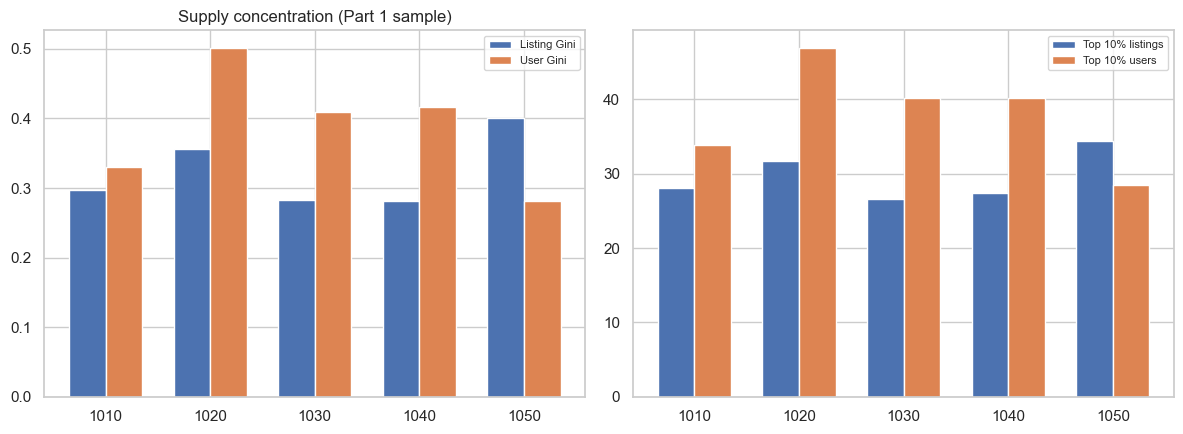

Saved /Users/dothinh_3112/Downloads/Datathon_Data/Thinh_Analyze/outputs/demand_side_1020/fig_gini_and_top10_from_part1.png


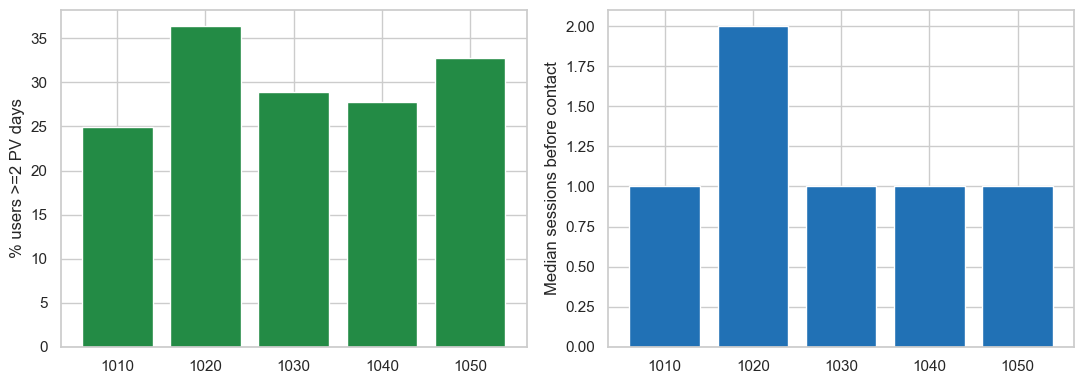

Saved /Users/dothinh_3112/Downloads/Datathon_Data/Thinh_Analyze/outputs/demand_side_1020/fig_demand_signals.png


In [4]:
print(f"Demand-side sample {SAMPLE_PCT}%...")
con.execute(f'''
    CREATE OR REPLACE TEMP TABLE base_events AS
    SELECT category, user_id, session_id, item_id, date, event_ts, event_type,
        CASE WHEN event_type IN ({EXPLICIT_SQL}) THEN 1 ELSE 0 END AS is_explicit,
        CASE WHEN event_type = 'pageview' THEN 1 ELSE 0 END AS is_pv,
        CASE WHEN event_type = 'pageview' AND query IS NOT NULL AND trim(CAST(query AS VARCHAR)) <> ''
             THEN regexp_replace(lower(trim(CAST(query AS VARCHAR))), '\\s+', ' ', 'g') ELSE NULL END AS qnorm
    FROM read_parquet('{EVENTS_GLOB}') TABLESAMPLE {SAMPLE_PCT} PERCENT (SYSTEM)
    WHERE {LOGIN_WHERE} AND category IN ({CAT_IN})
''')
con.execute('''
    CREATE OR REPLACE TEMP TABLE user_first_contact AS
    SELECT category, user_id, MIN(event_ts) AS t0, COUNT(DISTINCT item_id)::BIGINT AS contacted_listings
    FROM base_events WHERE is_explicit=1 AND item_id IS NOT NULL GROUP BY 1, 2
''')
con.execute('''
    CREATE OR REPLACE TEMP TABLE user_sessions AS
    WITH ss AS (
        SELECT category, user_id, session_id, MIN(event_ts) AS st FROM base_events
        WHERE session_id IS NOT NULL GROUP BY 1, 2, 3
    )
    SELECT s.category, s.user_id,
        SUM(CASE WHEN s.st < f.t0 THEN 1 ELSE 0 END)::BIGINT AS sessions_before_contact,
        COUNT(s.session_id)::BIGINT AS total_sessions
    FROM ss s JOIN user_first_contact f USING (category, user_id) GROUP BY 1, 2
''')
con.execute('''
    CREATE OR REPLACE TEMP TABLE user_pv_days AS
    SELECT e.category, e.user_id, COUNT(DISTINCT e.date)::BIGINT AS pv_days_before
    FROM base_events e JOIN user_first_contact f USING (category, user_id)
    WHERE e.is_pv=1 AND e.event_ts < f.t0 GROUP BY 1, 2
''')
con.execute('''
    CREATE OR REPLACE TEMP TABLE all_searches AS
    SELECT category, user_id, session_id, event_ts, qnorm,
        LAG(qnorm) OVER (PARTITION BY category, user_id, session_id ORDER BY event_ts) AS pq
    FROM base_events WHERE qnorm IS NOT NULL
''')
con.execute('''
    CREATE OR REPLACE TEMP TABLE user_refinements_before AS
    SELECT s.category, s.user_id,
        SUM(CASE WHEN s.pq IS NOT NULL AND s.qnorm <> s.pq THEN 1 ELSE 0 END)::BIGINT AS total_refinements
    FROM all_searches s JOIN user_first_contact f USING (category, user_id)
    WHERE s.event_ts < f.t0 GROUP BY 1, 2
''')

demand_df = con.execute('''
    SELECT c.category, COUNT(c.user_id)::BIGINT AS converting_users_sample,
        median(c.contacted_listings) AS median_contacted_listings,
        avg(c.contacted_listings) AS mean_contacted_listings,
        median(us.sessions_before_contact) AS median_sessions_before_contact,
        avg(CASE WHEN pd.pv_days_before >= 2 THEN 100.0 ELSE 0.0 END) AS pct_users_repeat_daily_2plus_pv_days,
        median(urb.total_refinements) AS median_total_refinements_before_contact
    FROM user_first_contact c
    LEFT JOIN user_sessions us USING (category, user_id)
    LEFT JOIN user_pv_days pd USING (category, user_id)
    LEFT JOIN user_refinements_before urb USING (category, user_id)
    GROUP BY c.category ORDER BY c.category
''').df()
demand_df["label"] = demand_df["category"].map(CAT_META)
show_df(demand_df, "Demand-side (sample)")
if EXPORT_CSV:
    demand_df.to_csv(OUT["demand"] / "01_demand_side_by_category_sampled.csv", index=False)

full_path = OUT["demand"] / "01_demand_side_by_category.csv"
if full_path.exists():
    show_df(pd.read_csv(full_path), "Demand-side FULL (tham chiếu)")

rank_metrics = [
    "median_contacted_listings",
    "median_sessions_before_contact",
    "pct_users_repeat_daily_2plus_pv_days",
    "median_total_refinements_before_contact",
]
rank_rows = [
    {
        "metric": m,
        "value_1020": demand_df.loc[demand_df["category"] == 1020, m].iloc[0],
        "rank_1020": int(demand_df.set_index("category")[m].rank(ascending=False).loc[1020]),
    }
    for m in rank_metrics
]
show_df(pd.DataFrame(rank_rows), "1020 rank (1 = cao nhất)")

merged = summary_p1.merge(demand_df, on="category", how="inner")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = np.arange(len(merged))
w = 0.35
axes[0].bar(x - w / 2, merged["listing_gini"], width=w, label="Listing Gini")
axes[0].bar(x + w / 2, merged["user_gini"], width=w, label="User Gini")
axes[0].set_xticks(x)
axes[0].set_xticklabels(merged["category"].astype(str))
axes[0].set_title("Supply concentration (Part 1 sample)")
axes[0].legend(fontsize=8)
axes[1].bar(x - w / 2, merged["listing_top_10pct_share"], width=w, label="Top 10% listings")
axes[1].bar(x + w / 2, merged["user_top_10pct_share"], width=w, label="Top 10% users")
axes[1].set_xticks(x)
axes[1].set_xticklabels(merged["category"].astype(str))
axes[1].legend(fontsize=8)
save_fig(OUT["demand"] / "fig_gini_and_top10_from_part1.png")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
x = np.arange(len(demand_df))
axes[0].bar(x, demand_df["pct_users_repeat_daily_2plus_pv_days"], color="#238b45")
axes[0].set_xticks(x)
axes[0].set_xticklabels(demand_df["category"].astype(str))
axes[0].set_ylabel("% users >=2 PV days")
axes[1].bar(x, demand_df["median_sessions_before_contact"], color="#2171b5")
axes[1].set_xticks(x)
axes[1].set_xticklabels(demand_df["category"].astype(str))
axes[1].set_ylabel("Median sessions before contact")
save_fig(OUT["demand"] / "fig_demand_signals.png")


## Part 4 — 1020 hesitation / reassurance

Nguồn: `filtered_events.parquet` (cat 1020) nếu có; else events + login filter.


1020: filtered_events.parquet


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**Time to first contact**

,users,p50,p75,p90,pct_same_day,pct_3plus_days
0,140402,0.0,14.0,56.0,55.17,37.5


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

**Repeat PV same listing**

,pairs,pct_2plus_pv,pct_3plus_pv
0,1067034,30.21,13.66


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**1020 let vs sell**

,ad_type,users,med_contact,mean_contact,pct_2plus_days
0,let,78395,2.0,5.78,40.39
1,sell,71533,2.0,8.54,45.75
2,unknown,6429,1.0,1.43,30.42


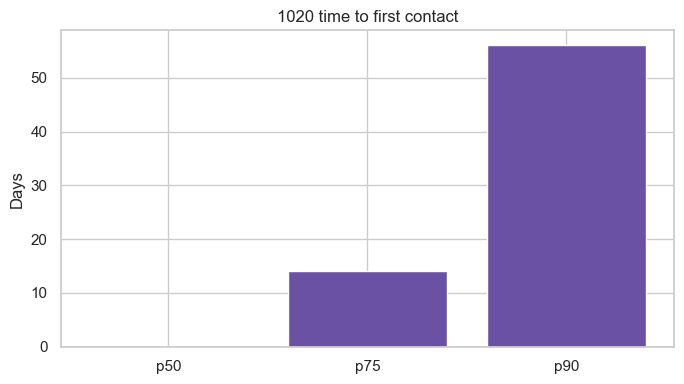

Saved /Users/dothinh_3112/Downloads/Datathon_Data/Thinh_Analyze/outputs/demand_side_1020/1020_deep_dive/fig_time_to_contact.png


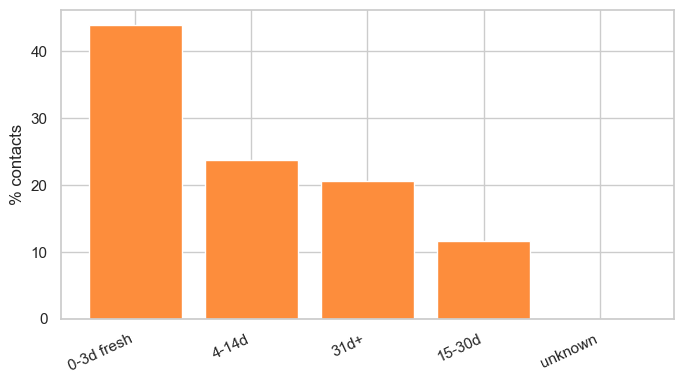

Saved /Users/dothinh_3112/Downloads/Datathon_Data/Thinh_Analyze/outputs/demand_side_1020/1020_deep_dive/fig_listing_age_at_contact.png


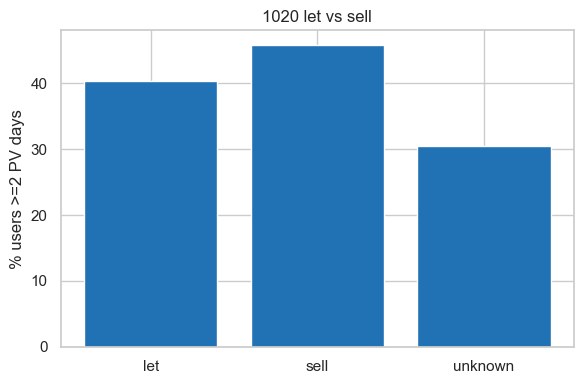

Saved /Users/dothinh_3112/Downloads/Datathon_Data/Thinh_Analyze/outputs/demand_side_1020/1020_deep_dive/fig_let_vs_sell_repeat.png


In [5]:
if USE_FILTERED:
    ev_from = f"read_parquet('{FILTERED_FILE.as_posix()}')"
    ev_where = f"category = {CAT_1020}"
    print("1020: filtered_events.parquet")
else:
    ev_from = f"read_parquet('{EVENTS_GLOB}')"
    ev_where = f"category = {CAT_1020} AND {LOGIN_WHERE}"
    print("1020: raw events login")

ttc = con.execute(f'''
    WITH ev AS (
        SELECT user_id, event_ts,
            CASE WHEN event_type IN ({EXPLICIT_SQL}) THEN 1 ELSE 0 END AS is_explicit,
            CASE WHEN event_type = 'pageview' THEN 1 ELSE 0 END AS is_pv
        FROM {ev_from} WHERE {ev_where}
    ),
    bounds AS (
        SELECT user_id,
            MIN(CASE WHEN is_pv=1 THEN event_ts END) AS first_pv_ts,
            MIN(CASE WHEN is_explicit=1 THEN event_ts END) AS first_contact_ts
        FROM ev GROUP BY 1
        HAVING first_pv_ts IS NOT NULL AND first_contact_ts IS NOT NULL
           AND first_contact_ts >= first_pv_ts
    ),
    lag AS (
        SELECT date_diff('day', CAST(first_pv_ts AS DATE), CAST(first_contact_ts AS DATE)) AS days
        FROM bounds
    )
    SELECT COUNT(*)::BIGINT AS users,
        ROUND(percentile_cont(0.5) WITHIN GROUP (ORDER BY days),1) AS p50,
        ROUND(percentile_cont(0.75) WITHIN GROUP (ORDER BY days),1) AS p75,
        ROUND(percentile_cont(0.9) WITHIN GROUP (ORDER BY days),1) AS p90,
        ROUND(100.0*SUM(CASE WHEN days=0 THEN 1 ELSE 0 END)/COUNT(*),2) AS pct_same_day,
        ROUND(100.0*SUM(CASE WHEN days>=3 THEN 1 ELSE 0 END)/COUNT(*),2) AS pct_3plus_days
    FROM lag
''').df()
show_df(ttc, "Time to first contact")
if EXPORT_CSV:
    ttc.to_csv(OUT["deep1020"] / "01_time_to_first_contact_days.csv", index=False)

fresh = con.execute(f'''
    WITH fc AS (
        SELECT user_id, CAST(item_id AS VARCHAR) AS item_id, MIN(CAST(date AS DATE)) AS contact_date
        FROM {ev_from}
        WHERE {ev_where} AND event_type IN ({EXPLICIT_SQL}) AND item_id IS NOT NULL
        GROUP BY 1, 2
    ),
    j AS (
        SELECT CASE WHEN s.listing_age_days IS NULL THEN 'unknown'
            WHEN s.listing_age_days <= 3 THEN '0-3d fresh'
            WHEN s.listing_age_days <= 14 THEN '4-14d'
            WHEN s.listing_age_days <= 30 THEN '15-30d' ELSE '31d+' END AS age_bucket,
            COUNT(*)::BIGINT AS n
        FROM fc
        LEFT JOIN read_parquet('{SNAP_GLOB}') s
            ON fc.item_id = CAST(s.item_id AS VARCHAR) AND fc.contact_date = CAST(s.date AS DATE)
        GROUP BY 1
    )
    SELECT *, ROUND(100.0*n/SUM(n) OVER(),2) AS pct FROM j ORDER BY n DESC
''').df()
show_df(fresh, "Listing age at contact")
if EXPORT_CSV:
    fresh.to_csv(OUT["deep1020"] / "02_contact_by_listing_age.csv", index=False)

repeat_pv = con.execute(f'''
    WITH ev AS (
        SELECT user_id, CAST(item_id AS VARCHAR) AS item_id, event_ts, event_type
        FROM {ev_from} WHERE {ev_where}
    ),
    fc AS (
        SELECT user_id, item_id, MIN(event_ts) AS t0
        FROM ev WHERE event_type IN ({EXPLICIT_SQL}) GROUP BY 1, 2
    ),
    pv AS (
        SELECT e.user_id, e.item_id, COUNT(*)::BIGINT AS n_pv
        FROM ev e JOIN fc f USING (user_id, item_id)
        WHERE e.event_type='pageview' AND e.event_ts < f.t0
        GROUP BY 1, 2
    )
    SELECT COUNT(*)::BIGINT AS pairs,
        ROUND(100.0*SUM(CASE WHEN n_pv>=2 THEN 1 ELSE 0 END)/COUNT(*),2) AS pct_2plus_pv,
        ROUND(100.0*SUM(CASE WHEN n_pv>=3 THEN 1 ELSE 0 END)/COUNT(*),2) AS pct_3plus_pv
    FROM pv
''').df()
show_df(repeat_pv, "Repeat PV same listing")
if EXPORT_CSV:
    repeat_pv.to_csv(OUT["deep1020"] / "03_repeat_pv_same_listing.csv", index=False)

split = con.execute(f'''
    WITH ev AS (
        SELECT e.user_id, e.session_id, CAST(e.item_id AS VARCHAR) AS item_id,
            e.date, e.event_ts, e.event_type,
            CASE WHEN e.event_type IN ({EXPLICIT_SQL}) THEN 1 ELSE 0 END AS is_explicit,
            CASE WHEN e.event_type='pageview' THEN 1 ELSE 0 END AS is_pv
        FROM {ev_from} e
        WHERE e.category = {CAT_1020}
    ),
    ev_ad AS (
        SELECT ev.*, COALESCE(d.ad_type,'unknown') AS ad_type
        FROM ev
        LEFT JOIN read_parquet('{DIM_GLOB}') d
            ON ev.item_id = CAST(d.item_id AS VARCHAR) AND d.category = {CAT_1020}
    ),
    fc AS (
        SELECT ad_type, user_id, MIN(event_ts) AS t0
        FROM ev_ad WHERE is_explicit=1 GROUP BY 1, 2
    ),
    pu AS (
        SELECT e.ad_type, e.user_id,
            COUNT(DISTINCT CASE WHEN e.is_explicit=1 THEN e.item_id END)::BIGINT AS contacted,
            COUNT(DISTINCT CASE WHEN e.is_pv=1 AND e.event_ts<f.t0 THEN e.date END)::BIGINT AS pv_days
        FROM ev_ad e
        JOIN fc f ON e.ad_type=f.ad_type AND e.user_id=f.user_id
        GROUP BY 1, 2
    )
    SELECT ad_type, COUNT(*)::BIGINT AS users,
        ROUND(median(contacted),1) AS med_contact,
        ROUND(avg(contacted),2) AS mean_contact,
        ROUND(100.0*SUM(CASE WHEN pv_days>=2 THEN 1 ELSE 0 END)/COUNT(*),2) AS pct_2plus_days
    FROM pu GROUP BY 1 ORDER BY users DESC
''').df()
show_df(split, "1020 let vs sell")
if EXPORT_CSV:
    split.to_csv(OUT["deep1020"] / "04_metrics_by_ad_type.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
if not ttc.empty:
    ax.bar(["p50", "p75", "p90"], [ttc.iloc[0]["p50"], ttc.iloc[0]["p75"], ttc.iloc[0]["p90"]], color="#6a51a3")
    ax.set_ylabel("Days")
    ax.set_title("1020 time to first contact")
save_fig(OUT["deep1020"] / "fig_time_to_contact.png")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(fresh["age_bucket"], fresh["pct"], color="#fd8d3c")
plt.xticks(rotation=25, ha="right")
ax.set_ylabel("% contacts")
save_fig(OUT["deep1020"] / "fig_listing_age_at_contact.png")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(split["ad_type"], split["pct_2plus_days"], color="#2171b5")
ax.set_ylabel("% users >=2 PV days")
ax.set_title("1020 let vs sell")
save_fig(OUT["deep1020"] / "fig_let_vs_sell_repeat.png")


## Part 5 — Login vs non-login + chat_message_count

QA trên `TABLESAMPLE {SAMPLE_PCT_QA}%`. **Kết luận:** non-login `contact_chat` trên mẫu join thường **0%** `chat_message_count > 0`; chat thật = login + (tuỳ chọn) `msg > 0`.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**Login vs non-login (10% sample)**

,is_login,events,pct_explicit,pct_positive
0,login,10207517,4.0519,51.2411
1,non-login,5959689,2.3154,73.8096


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**Session explicit rate**

...

**contact_chat x chat_message_count**

is_login,login,non-login
bucket,,
msg_gt0,71232.0,0.0
msg_zero,13622.0,4092.0
no_match,16341.0,3944.0


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**Top event types — non-login**

,is_login,event_type,n
0,non-login,other_interaction,4255539
1,non-login,pageview,1561541
2,non-login,view_phone,114815
3,non-login,contact_zalo,11563
4,non-login,contact_chat,8419
5,non-login,contact_sms,3503


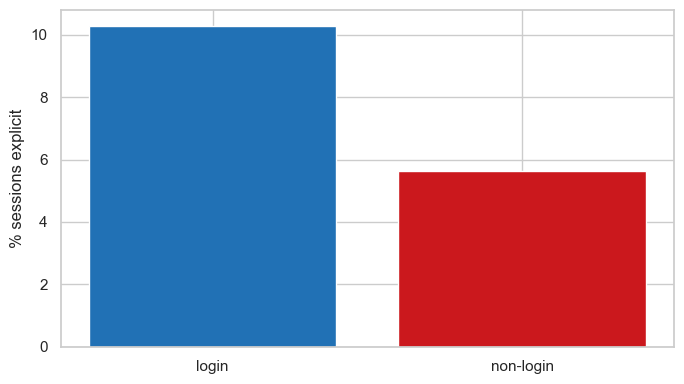

Saved /Users/dothinh_3112/Downloads/Datathon_Data/Thinh_Analyze/outputs/nonlogin_chat_qa/fig_session_explicit_rate.png


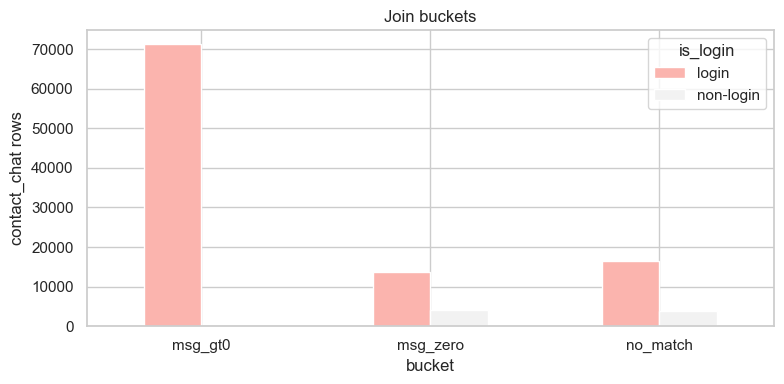

Saved /Users/dothinh_3112/Downloads/Datathon_Data/Thinh_Analyze/outputs/nonlogin_chat_qa/fig_chat_message_buckets.png


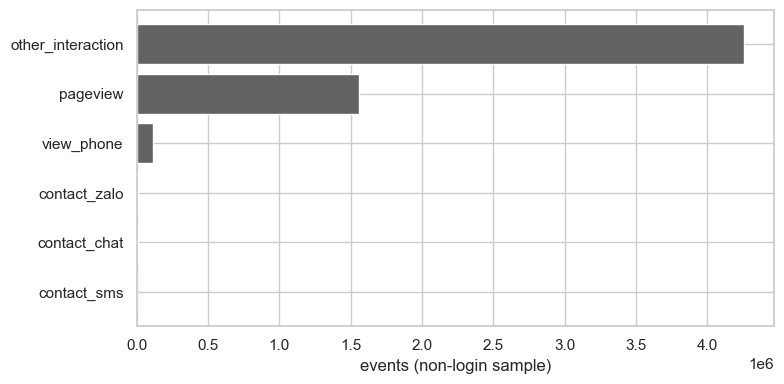

Saved /Users/dothinh_3112/Downloads/Datathon_Data/Thinh_Analyze/outputs/nonlogin_chat_qa/fig_nonlogin_event_mix.png


In [6]:
cmp = con.execute(f'''
    SELECT is_login, COUNT(*)::BIGINT AS events,
        ROUND(100.0*SUM(CASE WHEN event_type IN ({EXPLICIT_SQL}) THEN 1 ELSE 0 END)/COUNT(*),4) AS pct_explicit,
        ROUND(100.0*SUM(CASE WHEN event_type IN ({POSITIVE_SQL}) THEN 1 ELSE 0 END)/COUNT(*),4) AS pct_positive
    FROM read_parquet('{EVENTS_GLOB}') TABLESAMPLE {SAMPLE_PCT_QA} PERCENT (SYSTEM)
    WHERE is_login IN ('login','non-login') AND category IN ({CAT_IN})
    GROUP BY 1 ORDER BY 1
''').df()
show_df(cmp, f"Login vs non-login ({SAMPLE_PCT_QA}% sample)")

sess = con.execute(f'''
    WITH ev AS (
        SELECT session_id, is_login,
            MAX(CASE WHEN event_type IN ({EXPLICIT_SQL}) THEN 1 ELSE 0 END) AS has_explicit
        FROM read_parquet('{EVENTS_GLOB}') TABLESAMPLE {SAMPLE_PCT_QA} PERCENT (SYSTEM)
        WHERE session_id IS NOT NULL AND is_login IN ('login','non-login')
        GROUP BY 1, 2
    )
    SELECT is_login, COUNT(*)::BIGINT AS sessions,
        ROUND(100.0*SUM(has_explicit)/COUNT(*),2) AS pct_sess_explicit
    FROM ev GROUP BY 1
''').df()
show_df(sess, "Session explicit rate")
if EXPORT_CSV:
    cmp.to_csv(OUT["nonlogin"] / "01_login_vs_nonlogin_rates.csv", index=False)
    sess.to_csv(OUT["nonlogin"] / "02_session_explicit_rate.csv", index=False)

chat_cmp = con.execute(f'''
    WITH ev AS (
        SELECT is_login, CAST(user_id AS VARCHAR) AS user_id,
               CAST(item_id AS VARCHAR) AS item_id, CAST(date AS DATE) AS dt
        FROM read_parquet('{EVENTS_GLOB}') TABLESAMPLE {SAMPLE_PCT_QA} PERCENT (SYSTEM)
        WHERE event_type='contact_chat' AND is_contact=1 AND item_id IS NOT NULL
          AND is_login IN ('login','non-login')
    ),
    inter AS (
        SELECT CAST(user_id AS VARCHAR) AS user_id, CAST(item_id AS VARCHAR) AS item_id,
               CAST(date AS DATE) AS dt, chat_message_count
        FROM read_parquet('{INTER_GLOB}')
    ),
    joined AS (
        SELECT e.is_login,
            CASE WHEN i.user_id IS NULL THEN 'no_match'
                 WHEN COALESCE(i.chat_message_count,0)=0 THEN 'msg_zero'
                 ELSE 'msg_gt0' END AS bucket
        FROM ev e
        LEFT JOIN inter i ON e.user_id=i.user_id AND e.item_id=i.item_id AND e.dt=i.dt
    )
    SELECT is_login, bucket, COUNT(*)::BIGINT AS n FROM joined GROUP BY 1, 2 ORDER BY 1, 2
''').df()
pivot_chat = chat_cmp.pivot(index="bucket", columns="is_login", values="n").fillna(0)
show_df(pivot_chat, "contact_chat x chat_message_count")

mix = con.execute(f'''
    SELECT is_login, event_type, COUNT(*)::BIGINT AS n
    FROM read_parquet('{EVENTS_GLOB}') TABLESAMPLE {SAMPLE_PCT_QA} PERCENT (SYSTEM)
    WHERE is_login = 'non-login' AND category IN ({CAT_IN})
    GROUP BY 1, 2 ORDER BY n DESC LIMIT 12
''').df()
show_df(mix, "Top event types — non-login")

if EXPORT_CSV:
    chat_cmp.to_csv(OUT["nonlogin"] / "03_contact_chat_interaction_buckets.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(sess))
ax.bar(x, sess["pct_sess_explicit"], color=["#2171b5", "#cb181d"][: len(sess)])
ax.set_xticks(x)
ax.set_xticklabels(sess["is_login"])
ax.set_ylabel("% sessions explicit")
save_fig(OUT["nonlogin"] / "fig_session_explicit_rate.png")

if not pivot_chat.empty:
    pivot_chat.plot(kind="bar", figsize=(8, 4), colormap="Pastel1")
    plt.ylabel("contact_chat rows")
    plt.title("Join buckets")
    plt.xticks(rotation=0)
    plt.legend(title="is_login")
    save_fig(OUT["nonlogin"] / "fig_chat_message_buckets.png")

if not mix.empty:
    top = mix.head(8)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(top["event_type"], top["n"], color="#636363")
    ax.invert_yaxis()
    ax.set_xlabel("events (non-login sample)")
    save_fig(OUT["nonlogin"] / "fig_nonlogin_event_mix.png")


## Part 6 — Synthesis

- **Supply:** explicit contact tập trung (Gini, Pareto top 10%) — Part 1.
- **Catalog:** trùng title/geo sau time cut; 1050 thường nặng nhất — Part 2.
- **1020:** reassurance market — repeat multi-day, time-to-contact đuôi dài, tin fresh; sell chậm hơn let — Part 3–4.
- **Login:** funnel browse = session-level cả login/non-login; outcome/chat = login; non-login `contact_chat` không có msg>0 trên join — Part 5.
